# Week 9 Practical - Production ML Pipelines & CI/CD
### Turn a notebook that trains a model into a system that keeps working

**Your mission.** Build an automated, re-runnable pipeline: ingest -> validate ->
train -> evaluate -> conditional deploy, with a metric gate, an experiment log, tests,
and a CI workflow. By Friday you ship the pipeline plus a one-page CI/CD design note.

You are given `mlpipe.py` with function stubs, a `data/` folder (a golden `eval.csv`
and several training batches), and a `test_pipeline.py` to make pass.

> The two things that make a pipeline safe: a **validation gate** that stops bad data,
> and a **promotion gate** that never lets a worse model reach production. Fill every
> `# TODO`, then get `pytest` green.

## Part 0 - Setup

In [6]:
import os, json, inspect, subprocess, shutil, warnings
warnings.filterwarnings("ignore")
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import mlpipe
sns.set_theme(style="whitegrid")
if not os.path.exists("data/eval.csv"):
    subprocess.run(["python", "gen_data.py"], check=True)
print("ready")

ready


## Part 1 - The validation gate
Open `mlpipe.py` and complete `validate(df, schema)`. It must return `(ok, issues)` and
check: required columns present, null rate under the limit, numeric ranges, and allowed
categories for `shift` and the target. Then run it on a clean and an invalid batch.

*Hint: build a list of issue strings; `ok` is `len(issues) == 0`.*

In [7]:
ok, issues = mlpipe.validate(mlpipe.ingest("data/train.csv"))
print("train.csv       ok =", ok, " issues =", issues)

ok, issues = mlpipe.validate(mlpipe.ingest("data/train_invalid.csv"))
print("train_invalid.csv ok =", ok, " issues =", issues)

train.csv       ok = True  issues = []
train_invalid.csv ok = False  issues = ['avg_vibration out of range [0, 20]', "shift has unexpected values: ['twilight']"]


## Part 2 - Train and evaluate on the golden set
Complete `train(df, seed)` and `evaluate(model, df)` in `mlpipe.py`. Train on
`data/train.csv` and evaluate on `data/eval.csv`. Every run must be judged on this same
golden set.

*Hint: a scikit-learn `Pipeline` (ColumnTransformer + LogisticRegression); return AUC,
accuracy, F1.*

In [8]:
df_train = mlpipe.ingest("data/train.csv")
df_eval = mlpipe.ingest("data/eval.csv")

model = mlpipe.train(df_train, seed=9)
metrics = mlpipe.evaluate(model, df_eval)
print("metrics on golden eval set:", metrics)

metrics on golden eval set: {'auc': 0.8793, 'accuracy': 0.8, 'f1': 0.7727}


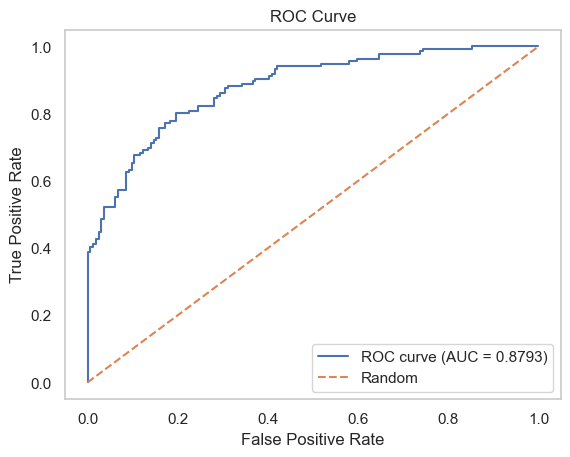

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_true = df_eval["high_defect"]
proba = model.predict_proba(
    df_eval[mlpipe.NUMERIC + mlpipe.CATEGORICAL]
)[:, 1]

fpr, tpr, thresholds = roc_curve(y_true, proba)
auc = roc_auc_score(y_true, proba)

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

## Part 3 - The promotion gate
Complete `promote(challenger, champion, threshold)`. A challenger is promoted only if
it clears the threshold **and** beats the champion; otherwise it is rejected. Show it
accepting a better model and rejecting a worse one.

*Hint: two conditions, two reject reasons, one promote.*

In [5]:
# challenger better than champion -> promote
print(mlpipe.promote({"auc": 0.90}, {"auc": 0.85}, threshold=0.80))

# challenger worse than champion -> reject
print(mlpipe.promote({"auc": 0.82}, {"auc": 0.88}, threshold=0.80))

# challenger below the absolute quality bar -> reject
print(mlpipe.promote({"auc": 0.70}, None, threshold=0.80))

('promote', 'clears threshold and beats champion')
('reject', 'AUC 0.82 does not beat champion 0.88')
('reject', 'AUC 0.7 below threshold 0.8')


## Part 4 - Run the pipeline across four scenarios
Complete `run_pipeline(train_path, eval_path, ...)` so it ingests, validates (and
blocks bad data), trains, evaluates, registers a version, applies the promotion gate,
and appends to `runs.csv`. Then run it on: baseline, invalid, drifted, improved. Track
the champion.

*Hint: return a record dict; on a validation failure set decision to `blocked` and
return early.*

In [6]:
shutil.rmtree("registry", ignore_errors=True)
if os.path.exists("runs.csv"):
    os.remove("runs.csv")

scenarios = [
    ("baseline", "data/train.csv"),        # clean batch
    ("invalid", "data/train_invalid.csv"), # malformed -> blocked by validation gate
    ("drifted", "data/train_drifted.csv"), # label noise -> passes validation, worse model, rejected
    ("improved", "data/train_v2.csv"),     # larger clean batch -> better model, promoted
]

for name, path in scenarios:
    rec = mlpipe.run_pipeline(path, "data/eval.csv", "registry", "runs.csv", run_id=name)
    champ = mlpipe.load_champion("registry")
    champ_version = champ["version"] if champ else None
    print(f"{name:10s} decision={rec['decision']:8s} auc={rec['auc']} "
          f"reason={rec['reason']:45s} champion={champ_version}")

baseline   decision=promote  auc=0.8793 reason=clears threshold and beats champion           champion=1
invalid    decision=blocked  auc=None reason=avg_vibration out of range [0, 20]; shift has unexpected values: ['twilight'] champion=1
drifted    decision=reject   auc=0.8589 reason=AUC 0.8589 does not beat champion 0.8793      champion=1
improved   decision=promote  auc=0.8808 reason=clears threshold and beats champion           champion=3


## Part 5 - Visualise and log
Read `runs.csv` into a table and plot each run's AUC coloured by decision, with the
threshold line. *(build the chart here)*

,run_id,seed,n_rows,auc,accuracy,f1,decision,version,reason
0,baseline,9,700,0.8793,0.8000,0.7727,promote,1.0,clears threshold and beats champion
1,invalid,9,0,NaN,NaN,NaN,blocked,NaN,"avg_vibration out of range [0, 20]; shift has ..."
2,drifted,9,1500,0.8589,0.7733,0.7236,reject,2.0,AUC 0.8589 does not beat champion 0.8793
3,improved,9,1500,0.8808,0.8033,0.7774,promote,3.0,clears threshold and beats champion


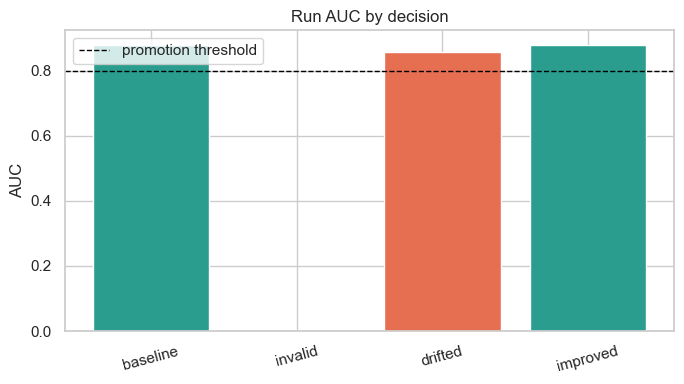

In [7]:
runs = pd.read_csv("runs.csv")
display(runs)

fig, ax = plt.subplots(figsize=(7, 4))
colors = runs["decision"].map({"promote": "#2a9d8f", "reject": "#e76f51", "blocked": "#adb5bd"})
ax.bar(runs["run_id"], runs["auc"].fillna(0), color=colors)
ax.axhline(0.80, color="black", linestyle="--", linewidth=1, label="promotion threshold")
ax.set_ylabel("AUC")
ax.set_title("Run AUC by decision")
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Part 6 - Tests and CI
Get the suite green, then read the CI workflow.

*Hint: from a terminal, `pytest -q`. Fix `mlpipe.py` until all tests pass.*

In [8]:
result = subprocess.run(["python", "-m", "pytest", "-q"], capture_output=True, text=True)
print(result.stdout[-800:])

# .github/workflows/ci.yml (once added to the repo) runs on every push/PR to main:
#   1. checkout + set up Python
#   2. pip install -r requirements.txt   (pinned deps, reproducible env)
#   3. pytest -q                          (fails the build on any red test)
#   4. python run_pipeline.py --train data/train.csv --eval data/eval.csv
#      -> exits 1 (fails build) only if the run is "blocked" by the validation gate;
#         a "reject" from the promotion gate is expected behaviour, exits 0.


...........                                                              [100%]
11 passed in 2.97s



## Part 7 - The CI/CD design note
## CI/CD Design Note: Defect Model Pipeline


## Pipeline

Five stages, defined once in mlpipe.py and run identically in the notebook, the tests, and CI:

ingest the incoming training batch.
validate it against a data contract (a gate).
train a scikit-learn pipeline (scaling, one-hot encoding, logistic regression).
evaluate on a fixed golden evaluation set.
promote the model only if it clears the gate (a gate).
The two gates
Validation gate. Checks required columns, null rate, numeric ranges, and allowed categories. A malformed batch is blocked before any training happens — this is what stopped train_invalid.csv (out-of-range vibration values, an unexpected "twilight" shift category) in my Part 4 run. In CI, a blocked run fails the build.
Promotion gate. A challenger becomes champion only if its AUC clears an absolute threshold and beats the current champion. Otherwise it is rejected and the champion stays. This is what caught train_drifted.csv: it passed validation cleanly (well-formed data) but the label noise produced a worse model (AUC 0.859 vs. the champion's 0.879), so it was correctly rejected.

These two gates are complementary and catch different failure modes: validation catches data that is broken; the promotion gate catches data that is intact but wrong. A threshold alone would let a "good enough" model overwrite a better one already in production; requiring the challenger to beat the champion alone would let a bad model through if no champion exists yet. Together they act as both a floor and a ratchet.

## Experiment tracking and registry

Every run appends a row to runs.csv (run id, rows, metrics, decision, version, reason). Every trained model is written to a versioned registry (model_vN.joblib) with its metrics recorded in manifest.json, and champion.json names the model currently in production. Any decision can be traced back to an exact model artifact.

## CI

On every push to main and every pull request, the CI job:

installs pinned dependencies from requirements.txt,
runs the test suite (pytest -q),
runs the pipeline on the latest data (run_pipeline.py).

A rejected challenger does not fail the build — the gate did its job, keeping a worse model out. Blocked data does fail the build, since a malformed batch is a real problem worth an engineer's attention.

## CD

A deploy step promotes the champion to the serving endpoint only when the CI job is green and the run actually promoted a new challenger (not every green build deploys). Rollback is a pointer change: set the champion alias in champion.json back to the previous version — no retraining required.

## Reproducibility

Fixed random seeds for the split and the model, pinned dependencies in requirements.txt, a fixed golden evaluation set (eval.csv) so every challenger is judged on identical data, and versioned artifacts. Re-running the pipeline on the same inputs yields the same decision.

## Triggers and cadence

Run on code changes (push, PR) and on a schedule when new data lands. Each run retrains and re-evaluates; promotion always goes through the gate. Retrain immediately if monitoring shows the input distribution has shifted.

## Limitations

Synthetic tabular data and a single metric (AUC). A production version of this system would need to gate on several metrics plus slice-level checks (e.g. per machine, per shift), add live data-drift monitoring on production inputs, and require human sign-off for large promotions.*